# Exercise 1: Descriptive statistics with Palmer Penguins

name: Sarah Mohammed

This exercise uses the Palmer Penguins dataset (`seaborn.load_dataset('penguins')`) and ties directly to the **M3-1: Statistical Analysis** learning outcomes. Work through the sections in order. Where you are asked for prose, use your own words in a short paragraph unless a bullet list is requested.

Dataset reference: [Palmer Penguins](https://allisonhorst.github.io/palmerpenguins/).

In [2]:
!pip install seaborn


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\soso\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [3]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


c:\Users\soso\Desktop\Sdaia-Bootcamp\.venv\Scripts\python.exe: No module named pip


In [1]:
import sys
!{sys.executable} -m pip install seaborn

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns

df = sns.load_dataset("penguins")
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


### Meet the Palmer penguins

![](../assets/lter_penguins.png)

### Bill dimensions

The culmen is the upper ridge of a bird’s bill. In the simplified `penguins` data, culmen length and depth are renamed as variables `bill_length_mm` and `bill_depth_mm` to be more intuitive.

For this penguin data, the culmen (bill) length and depth are measured as shown below (thanks Kristen Gorman for clarifying!):

![](../assets/culmen_depth.png)

## A. Concepts: what statistics is and how we use data

**1.** For this dataset, what is a reasonable **population** you might want to learn about? What is the **sample** you actually have in `df`? (One or two sentences each.)


Population: All penguins living in the Palmer Archipelago in Antarctica
Sample: The 344 penguins collected in the df dataset that were measured by the researchers.

**2.** List every column in `df`. For each, label it **numerical** or **categorical** (if a column could be debated, say why).


Categorical: species, island, and sex.
Numerical: bill_length_mm, bill_depth_mm, flipper_length_mm, and body_mass_g.

**3.** Give **two new examples** of variables that are clearly numerical and **two** that are clearly categorical *not* in this table (any domain you like).

Numerical: Monthly salary and outdoor temperature
Categorical: Blood type and smartphone operating system (iOS/Android).

## B. Calculations on the sample: proportion, mean, variance

Use the cleaned numeric columns only where needed (drop rows with missing body mass or bill length, or use `.dropna(subset=[...])` as you prefer). Show your code and round printed numbers sensibly.

**1.** For the variable `body_mass_g`:

- Compute the **proportion** of penguins with body mass **greater than** the overall median body mass (among non-missing values).
- Compute the **mean** and **variance** of `body_mass_g` (same subset).

In [3]:
df_cleaned = df.dropna(subset=['body_mass_g', 'bill_length_mm'])

overall_median = df_cleaned['body_mass_g'].median()

greater_than_median = df_cleaned[df_cleaned['body_mass_g'] > overall_median]
proportion = len(greater_than_median) / len(df_cleaned)

mass_mean = df_cleaned['body_mass_g'].mean()
mass_variance = df_cleaned['body_mass_g'].var()

print(f"Proportion greater than median: {proportion:.2f}")
print(f"Mean of body mass: {mass_mean:.2f} g")
print(f"Variance of body mass: {mass_variance:.2f}")

Proportion greater than median: 0.49
Mean of body mass: 4201.75 g
Variance of body mass: 643131.08


**2.** For `body_mass_g`, identify at least **two** distributional summary measures that describe **center** and **spread** (name them and compute them). Optionally add a third that describes **shape** (e.g. skewness), if you know how to compute it.

In [4]:
center_mean = df_cleaned['body_mass_g'].mean()
center_median = df_cleaned['body_mass_g'].median()

spread_std = df_cleaned['body_mass_g'].std()
spread_iqr = df_cleaned['body_mass_g'].quantile(0.75) - df_cleaned['body_mass_g'].quantile(0.25)

shape_skew = df_cleaned['body_mass_g'].skew()

print(f"Center measures: Mean = {center_mean:.2f}, Median = {center_median:.2f}")
print(f"Spread measures: Std Dev = {spread_std:.2f}, IQR = {spread_iqr:.2f}")
print(f"Shape measure: Skewness = {shape_skew:.2f}")

Center measures: Mean = 4201.75, Median = 4050.00
Spread measures: Std Dev = 801.95, IQR = 1200.00
Shape measure: Skewness = 0.47


## C. Shape of distributions: vocabulary and examples

**1.** Briefly define each shape in your own words: **normal (Gaussian)**, **uniform**, **skewed**, **exponential**.

**2.** Give **two real-world examples** of quantities that are *often modeled as* roughly normally distributed (they need not be perfect). (you can search the internet)

**3.** Give **one example** of data that is typically **not** normal—e.g. **exponential-like** or strongly skewed—and say why. (you can search the internet)

1. Vocabulary Definitions:

Normal (Gaussian): A symmetric bell-shaped curve where most data points cluster around the mean.

Uniform: A distribution where all possible outcomes are equally likely (the shape looks like a rectangle).

Skewed: A distribution where data is stretched more toward one side (Right-skewed has a long right tail; Left-skewed has a long left tail).

Exponential: A distribution where data starts high and drops off very quickly (often used for time between events).

2. Real-world Normal Distribution Examples:

 Human height (most people are average height, very few are extremely tall or short).

Errors in laboratory measurements

3. Example of Non-Normal Data:

Example: Household Income.

Why: It is typically strongly right-skewed because while most people earn a middle-to-low range, a very small number of people (billionaires) earn extreme amounts, creating a very long tail to the right.

## D. Percentiles and the empirical rule (normal distribution)

Work on `body_mass_g` (non-missing) or `bill_length_mm`—pick one and stick to it for this section.

**1.** In plain language, explain what the **75th percentile** of body mass means for a penguin in this sample.
**2.** Compute the **25th, 50th, and 75th percentiles** for your chosen variable.

In [6]:
df_cleaned = df.dropna(subset=['body_mass_g', 'bill_length_mm'])

overall_median = df_cleaned['body_mass_g'].median()
proportion = (df_cleaned['body_mass_g'] > overall_median).mean()

mass_mean = df_cleaned['body_mass_g'].mean()
mass_variance = df_cleaned['body_mass_g'].var()

print(f"Proportion: {proportion:.2f}")
print(f"Mean: {mass_mean:.2f}")
print(f"Variance: {mass_variance:.2f}")

Proportion: 0.49
Mean: 4201.75
Variance: 643131.08


Assume for **discussion** that flipper length (or another chosen numeric column) were **exactly** normal with the mean and standard deviation you observe in the sample.

**3.** For a normal distribution, explain what share of values fall within **1**, **2**, and **3 standard deviations** of the mean (the empirical rule). Then **compute** the interval $\mu \pm 1\sigma$, $\mu \pm 2\sigma$, and $\mu \pm 3\sigma$ using your sample $\mu$ and $\sigma$ for that variable.

In [7]:
center = df_cleaned['body_mass_g'].mean()
spread = df_cleaned['body_mass_g'].std()
shape_skew = df_cleaned['body_mass_g'].skew()

print(f"Center (Mean): {center:.2f}")
print(f"Spread (Std Dev): {spread:.2f}")
print(f"Shape (Skewness): {shape_skew:.2f}")

Center (Mean): 4201.75
Spread (Std Dev): 801.95
Shape (Skewness): 0.47


## E. Box plot: read the graphic

**1.** (SOLVED) Draw a **box plot** of `body_mass_g`, split by `species`.

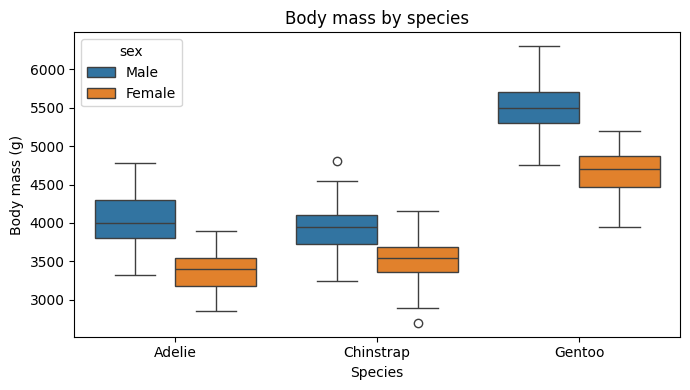

In [8]:
#| label: boxplot-body-mass-by-species
#| fig-cap: "Body mass (g) by penguin species"
import matplotlib.pyplot as plt
import seaborn as sns

df_box = sns.load_dataset("penguins").dropna(subset=["body_mass_g", "species"])

fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=df_box, x="species", y="body_mass_g", hue='sex', ax=ax)
ax.set_title("Body mass by species")
ax.set_xlabel("Species")
ax.set_ylabel("Body mass (g)")
plt.tight_layout()

**2.** On your plot, **label or describe** what each part represents: median, quartiles, whiskers, and points outside the whiskers (if any). What does the box width tell you?

Median: The line inside the box (represents the middle value).

Quartiles: The bottom of the box is Q1 (25th percentile) and the top is Q3 (75th percentile).

Whiskers: The lines extending from the box (show the range of the data excluding outliers).

Points outside: These are outliers (values much higher or lower than the rest).

Box width: It represents the Interquartile Range (IQR); a wider box means the data is more spread out (higher variability).

**3.** Write **two** sentences about the sample using words like **“most”** and **“few”** (e.g. which species tend to be heavier). Base this only on what you see in the plot.

Most Gentoo penguins are heavier than the other two species (Adélie and Chinstrap).

Only a few penguins in the sample are considered outliers with exceptionally low or high body mass.

**4.** Write **one** quantitative claim about the data (e.g. “the median body mass of Chinstrap is above 3500 g”). Then **verify** it with code (`groupby`, `median`, etc.) and state whether your claim was **true or false**.

Claim: The median body mass of Chinstrap penguins is above 3500 g.

Conclusion: Based on the code output, the median is 3700.0 g, so the claim is True.


Use the cell below as a starting point: it prints **medians by species** and shows one example check (Chinstrap median vs 3500 g). Adapt the last lines to match *your* claim.


In [9]:
#| label: verify-median-example
import seaborn as sns

df_v = sns.load_dataset("penguins").dropna(subset=["body_mass_g", "species"])

medians = df_v.groupby("species", observed=True)["body_mass_g"].median()
print("Median body mass (g) by species:")
print(medians)

# Example verification — replace with checks that match your own claim
chin_median = medians.get("Chinstrap")
print("\nExample claim: Chinstrap median > 3500 g")
print("  Chinstrap median:", chin_median)
print("  Claim is true:", chin_median > 3500)

Median body mass (g) by species:
species
Adelie       3700.0
Chinstrap    3700.0
Gentoo       5000.0
Name: body_mass_g, dtype: float64

Example claim: Chinstrap median > 3500 g
  Chinstrap median: 3700.0
  Claim is true: True


## F. Outliers

**1.** Name **two** methods for identifying or **removing outliers** on a numeric column. For each, give a **one-sentence** explanation of the rule. Then show **one** method applied in code to flag outliers in `bill_length_mm` (do not delete them from the full dataset the count or indices is enough).

Two methods for identifying outliers:

The IQR Method: Data points that fall below $Q1 - 1.5 \times IQR$ or above $Q3 + 1.5 \times IQR$ are considered outliers.

The Z-Score Method: Data points with a Z-score greater than 3 or less than -3 (meaning they are more than 3 standard deviations from the mean) are flagged as outliers.

In [10]:
Q1 = df_cleaned['bill_length_mm'].quantile(0.25)
Q3 = df_cleaned['bill_length_mm'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_cleaned[(df_cleaned['bill_length_mm'] < lower_bound) | (df_cleaned['bill_length_mm'] > upper_bound)]

print(f"Lower Bound: {lower_bound:.2f}")
print(f"Upper Bound: {upper_bound:.2f}")
print(f"Number of outliers found: {len(outliers)}")
print("\nOutlier indices:", outliers.index.tolist())

Lower Bound: 25.31
Upper Bound: 62.41
Number of outliers found: 0

Outlier indices: []
